In [13]:
# import libraries
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
import pandas as pd

url = "../data/processed/stops_clean.csv.gz"

stops = pd.read_csv(url)

stops.head()

/var/folders/b7/4yf7b9tn1t1ck0mv8h93dssc0000gn/T/ipykernel_33515/2832472583.py:5: DtypeWarning: Columns (0,6) have mixed types. Specify dtype option on import or set low_memory=False.
  stops = pd.read_csv(url)


,raw_row_number,date,time,location,lat,lng,district,zone,subject_age,subject_race,...,Male,Female,y_arrest,stop_date,stop_time,stop_datetime,stop_hour,stop_dow,stop_month,stop_year
0,149223,2012-01-01,13:01:00,Barracks St & N Peters St,29.960840,-90.057711,8,E,35.0,black,...,743.0,543.0,0,2012-01-01,0 days 13:01:00,2012-01-01 13:01:00,13,6,1,2012
1,149149,2012-01-01,13:08:00,Dumaine St & N Rampart St,29.962113,-90.066910,8,E,26.0,white,...,1286.0,784.0,0,2012-01-01,0 days 13:08:00,2012-01-01 13:08:00,13,6,1,2012
2,149086,2012-01-01,01:11:00,S Carrollton Ave & Olive St,29.963036,-90.112752,2,T,27.0,black,...,1035.0,1315.0,0,2012-01-01,0 days 01:11:00,2012-01-01 01:11:00,1,6,1,2012
3,149225,2012-01-01,13:12:00,Barracks St & N Peters St,29.960840,-90.057711,8,E,19.0,white,...,743.0,543.0,0,2012-01-01,0 days 13:12:00,2012-01-01 13:12:00,13,6,1,2012
4,149081,2012-01-01,01:13:00,S Rendon & Washington,29.961357,-90.099890,2,V,67.0,white,...,617.0,1154.0,0,2012-01-01,0 days 01:13:00,2012-01-01 01:13:00,1,6,1,2012


In [15]:
stops.shape

(274657, 77)

In [16]:
stops.columns

Index(['raw_row_number', 'date', 'time', 'location', 'lat', 'lng', 'district',
       'zone', 'subject_age', 'subject_race', 'subject_sex',
       'officer_assignment', 'type', 'arrest_made', 'citation_issued',
       'warning_issued', 'outcome', 'contraband_found', 'contraband_drugs',
       'contraband_weapons', 'frisk_performed', 'search_conducted',
       'search_person', 'search_vehicle', 'search_basis', 'reason_for_stop',
       'vehicle_color', 'vehicle_make', 'vehicle_model', 'vehicle_year',
       'raw_actions_taken', 'raw_subject_race', 'final_lat', 'final_lng',
       'geometry', 'index_right', 'STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID',
       'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT',
       'INTPTLON', 'Geographic Area Name',
       'Total!!Estimate!!Population 25 years and over',
       'Total!!Estimate!!Population 25 years and over!!Less than 9th grade',
       'Total!!Estimate!!Population 25 years and over!!9th to 12th grade, no diploma',
  

### Random Forest

#### arrest or not

In [17]:
# random forest modeling (stop-level) with tract-aware split
# target: arrest vs not arrest

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)

from sklearn.ensemble import RandomForestClassifier

# create target/check if already exists
stops = stops.copy()
if "y_arrest" not in stops.columns:
    if "outcome" in stops.columns:
        stops["y_arrest"] = (stops["outcome"].astype(str).str.lower() == "arrest").astype(int)
    elif "arrest_made" in stops.columns:
        stops["y_arrest"] = stops["arrest_made"].astype(int)
    else:
        raise ValueError("Could not find an arrest indicator. Need either 'outcome' or 'arrest_made'.")

# create time features
dt_col = None
for c in ["date", "stop_datetime", "datetime", "stop_date"]:
    if c in stops.columns:
        dt_col = c
        break

if dt_col is not None:
    dt = pd.to_datetime(stops[dt_col], errors="coerce")
    stops["stop_hour"] = dt.dt.hour
    stops["stop_dow"] = dt.dt.dayofweek
    stops["stop_month"] = dt.dt.month
    stops["stop_year"] = dt.dt.year

# define candidate features
# individual-level predictors
candidate_individual = [
    "subject_race",
    "subject_sex",
    "subject_age",
    "reason_for_stop",
    "violation",
    "stop_hour",
    "stop_dow",
    "stop_month",
    "stop_year",
]

# tract level predictors
candidate_acs = [
    # income
    "Mean household income (dollars)",
    "Median household income (dollars)",
    # race composition
    "perc_black",
    "perc_white",
    # education bins
    "Less than 9th grade",
    "9th to 12th grade, no diploma",
    "High school graduate (includes equivalency)",
    "Some college, no degree",
    "Bachelor's degree",
    "Graduate or professional degree",
    # total pop
    "Total population",
]

candidate_tract_id = []

candidate_features = candidate_individual + candidate_acs + candidate_tract_id
feature_cols = [c for c in candidate_features if c in stops.columns]

if len(feature_cols) == 0:
    raise ValueError("No feature columns found. Check your column names in `stops.columns`.")

# drop rows missing GEOID
if "GEOID" not in stops.columns:
    raise ValueError("Need 'GEOID' column for tract-aware splitting. Make sure your ACS merge kept GEOID.")

model_df = stops.dropna(subset=["y_arrest", "GEOID"]).copy()

X = model_df[feature_cols]
y = model_df["y_arrest"].astype(int)
groups = model_df["GEOID"].astype(str)

# preprocess by imputing and one hot encoding categoricals
cat_cols = [c for c in X.columns if X[c].dtype == "object" or str(X[c].dtype).startswith("category")]
num_cols = [c for c in X.columns if c not in cat_cols]
numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)
categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
)

# tract aware train/test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# random forest model
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
    max_depth=None,
    min_samples_leaf=10,
)

pipe = Pipeline(
    steps=[
        ("prep", preprocess),
        ("rf", rf),
    ]
)

pipe.fit(X_train, y_train)

# evaluate results
pred = pipe.predict(X_test)
proba = pipe.predict_proba(X_test)[:, 1]

print("Confusion matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification report:\n", classification_report(y_test, pred, digits=3))
print("ROC AUC:", roc_auc_score(y_test, proba))
print("Avg Precision (PR AUC):", average_precision_score(y_test, proba))

# feature importance
# get expanded feature names after preprocessing
prep = pipe.named_steps["prep"]

feature_names = []
if len(num_cols) > 0:
    feature_names.extend(num_cols)

if len(cat_cols) > 0:
    ohe = prep.named_transformers_["cat"].named_steps["onehot"]
    ohe_names = ohe.get_feature_names_out(cat_cols).tolist()
    feature_names.extend(ohe_names)

importances = pipe.named_steps["rf"].feature_importances_

fi = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 25 feature importances:")
print(fi.head(25).to_string(index=False))


Confusion matrix:
 [[21222  6223]
 [ 2842  3766]]

Classification report:
               precision    recall  f1-score   support

           0      0.882     0.773     0.824     27445
           1      0.377     0.570     0.454      6608

    accuracy                          0.734     34053
   macro avg      0.629     0.672     0.639     34053
weighted avg      0.784     0.734     0.752     34053

ROC AUC: 0.729833839481737
Avg Precision (PR AUC): 0.4116544742465283

Top 25 feature importances:
                                             feature  importance
                                         subject_age    0.270086
                   reason_for_stop_TRAFFIC VIOLATION    0.162301
                                           stop_year    0.129423
                                          stop_month    0.117212
                  reason_for_stop_CRIMINAL VIOLATION    0.099795
                                            stop_dow    0.076225
                    reason_for_stop_CALL FOR

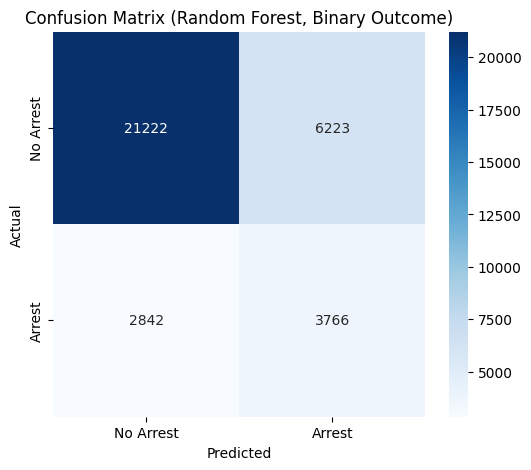

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

classes = ["No Arrest", 'Arrest']

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Random Forest, Binary Outcome)")
plt.show()

In [19]:
rename_dict = {
    "subject_age": "Subject Age",
    "stop_month": "Month",
    "stop_year": "Year",
    "stop_dow": "Day of Week",
    "stop_hour": "Hour",

    "subject_race_black": "Driver Race: Black",
    "subject_race_white": "Driver Race: White",
    "subject_race_hispanic": "Driver Race: Hispanic",
    'subject_race_asian/pacific islander': 'Driver Race: Asian/Pacific Islander',
    'subject_race_unknown': 'Driver Race: Unknown',
    'subject_race_other': 'Driver Race: Other',

    "subject_sex_male": "Driver Sex: Male",
    "subject_sex_female": "Driver Sex: Female",

    "reason_for_stop_TRAFFIC VIOLATION": "Stop Reason: Traffic Violation",
    "reason_for_stop_SUSPECT PERSON": "Stop Reason: Suspect Person",
    "reason_for_stop_CRIMINAL VIOLATION": "Stop Reason: Criminal Violation",
    "reason_for_stop_CALL FOR SERVICE": "Stop Reason: Call for Service",
    'reason_for_stop_JUVENILE VIOLATION': 'Stop Reason: Juvenile Violation',
    'reason_for_stop_CITIZEN CONTACT': 'Stop Reason: Citizen Contact',
    'reason_for_stop_OTHER': 'Stop Reason: Other',
    'reason_for_stop_SUSPECT VEHICLE': 'Stop Reason: Suspect Vehicle',
    'reason_for_stop_FLAGGED DOWN': 'Stop Reason: Flagged Down',
    'reason_for_stop_PRESENT AT CRIME SCENE': 'Stop Reason: Present at Crime Scene',
    'reason_for_stop_CALL FOR SERVICE|TRAFFIC VIOLATION': 'Stop Reason: Call for Service + Traffic Violation',

    'Total!!Estimate!!Population 25 years and over!!Some college, no degree': 'Some college, no degree',
    'Total!!Estimate!!Population 25 years and over!!High school graduate (includes equivalency)': 'High school graduate',
    'Total!!Estimate!!Population 25 years and over!!9th to 12th grade, no diploma': '9th to 12th grade, no diploma',
    'Total!!Estimate!!Population 25 years and over!!Less than 9th grade': 'Less than 9th grade',
    'Total!!Estimate!!Population 25 years and over!!Graduate or professional degree': 'Graduate or professional degree',
    'Total!!Estimate!!Population 25 years and over!!Bachelor\'s degree': 'Bachelor\'s degree',
    'Total!!Estimate!!Population 25 years and over!!Associate\'s degree': 'Associate\'s degree',

    'Households!!Estimate!!Mean income (dollars)': 'Mean income (dollars)',
    'Households!!Estimate!!Median income (dollars)': 'Median income (dollars)',
}


fi["feature_clean"] = fi["feature"].replace(rename_dict)

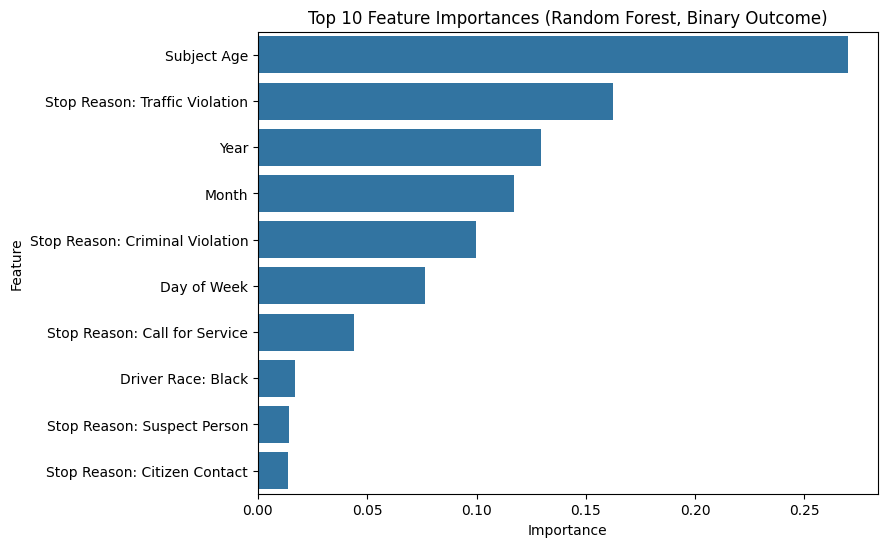

In [20]:
plt.figure(figsize=(8, 6))
sns.barplot(data=fi.head(10), x='importance', y='feature_clean')
plt.title('Top 10 Feature Importances (Random Forest, Binary Outcome)')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

#### which type of arrest

In [21]:
# random forest (multiclass) outcome model
# predicts outcome and tract-aware split (by GEOID) to reduce leakage

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    log_loss,
)

# checks
stops = stops.copy()

if "outcome" not in stops.columns:
    raise ValueError("Expected stops['outcome'] to exist with values like None/Warning/Citation/Arrest.")

if "GEOID" not in stops.columns:
    raise ValueError("Need stops['GEOID'] for tract-aware splitting.")

# Normalize outcome labels
stops["outcome"] = stops["outcome"].astype(str).str.strip()
stops.loc[stops["outcome"].isin(["nan", "NaN", "NoneType", ""]), "outcome"] = "None"

allowed = {"None", "Warning", "Citation", "Arrest"}
stops = stops[stops["outcome"].isin(allowed)].copy()

# create time features
dt_col = None
for c in ["date", "stop_datetime", "datetime", "stop_date"]:
    if c in stops.columns:
        dt_col = c
        break

if dt_col is not None:
    dt = pd.to_datetime(stops[dt_col], errors="coerce")
    stops["stop_hour"] = dt.dt.hour
    stops["stop_dow"] = dt.dt.dayofweek
    stops["stop_month"] = dt.dt.month
    stops["stop_year"] = dt.dt.year

# select features
candidate_individual = [
    "subject_race",
    "subject_sex",
    "subject_age",
    "reason_for_stop",
    "stop_hour",
    "stop_dow",
    "stop_month",
    "stop_year",
]

# add tract-level ACS features
candidate_acs = [
    "Mean household income (dollars)",
    "Median household income (dollars)",
    "perc_black",
    "perc_white",
    "Less than 9th grade",
    "9th to 12th grade, no diploma",
    "High school graduate (includes equivalency)",
    "Some college, no degree",
    "Bachelor's degree",
    "Graduate or professional degree",
    "Total population",
]

feature_cols = [c for c in (candidate_individual + candidate_acs) if c in stops.columns]
if len(feature_cols) == 0:
    raise ValueError("No feature columns found. Check column names in stops.columns.")

X = stops[feature_cols].copy()
y = stops["outcome"].copy()
groups = stops["GEOID"].astype(str).copy()

# tract aware train/test split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# preprocessing impute and one hot encode
cat_cols = [c for c in X.columns if X[c].dtype == "object" or str(X[c].dtype).startswith("category")]
num_cols = [c for c in X.columns if c not in cat_cols]

numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
)

# random forest
rf = RandomForestClassifier(
    n_estimators=600,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
    min_samples_leaf=10,
)

pipe = Pipeline(steps=[("prep", preprocess), ("rf", rf)])
pipe.fit(X_train, y_train)

# evaluate results
pred = pipe.predict(X_test)
proba = pipe.predict_proba(X_test)   # shape: (n, n_classes)
classes = pipe.named_steps["rf"].classes_

print("Classes:", classes)
print("\nConfusion matrix (rows=actual, cols=pred):")
print(confusion_matrix(y_test, pred, labels=classes))

print("\nClassification report:")
print(classification_report(y_test, pred, digits=3))

# multiclass log loss
print("Log loss:", log_loss(y_test, proba, labels=classes))

try:
    auc_ovr = roc_auc_score(
        pd.get_dummies(y_test).reindex(columns=classes, fill_value=0).values,
        proba,
        multi_class="ovr"
    )
    print("ROC AUC (OvR):", auc_ovr)
except Exception as e:
    print("ROC AUC (OvR) not computed:", e)

# average precision per class (one-vs-rest)
y_test_bin = pd.get_dummies(y_test).reindex(columns=classes, fill_value=0)
ap_per_class = {}
for i, cls in enumerate(classes):
    try:
        ap_per_class[cls] = average_precision_score(y_test_bin[cls], proba[:, i])
    except Exception:
        ap_per_class[cls] = np.nan

print("\nAverage Precision (PR AUC) per class:")
for k, v in ap_per_class.items():
    print(f"  {k}: {v}")

# feature importance
prep = pipe.named_steps["prep"]

feature_names = []
if len(num_cols) > 0:
    feature_names.extend(num_cols)

if len(cat_cols) > 0:
    ohe = prep.named_transformers_["cat"].named_steps["onehot"]
    feature_names.extend(ohe.get_feature_names_out(cat_cols).tolist())

importances = pipe.named_steps["rf"].feature_importances_
fi = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 30 feature importances:")
print(fi.head(30).to_string(index=False))



Classes: ['Arrest' 'Citation' 'None' 'Warning']

Confusion matrix (rows=actual, cols=pred):
[[2616 1378 1673  941]
 [ 963 4691  740 3307]
 [1479  766 5202  710]
 [ 874 3554 1420 3739]]

Classification report:
              precision    recall  f1-score   support

      Arrest      0.441     0.396     0.417      6608
    Citation      0.452     0.484     0.467      9701
        None      0.576     0.638     0.605      8157
     Warning      0.430     0.390     0.409      9587

    accuracy                          0.477     34053
   macro avg      0.475     0.477     0.475     34053
weighted avg      0.473     0.477     0.474     34053

Log loss: 1.147727388554921
ROC AUC (OvR): 0.7425179034295162

Average Precision (PR AUC) per class:
  Arrest: 0.412368143025873
  Citation: 0.46988767620957533
  None: 0.6019325803218164

Top 30 feature importances:
                                             feature  importance
                   reason_for_stop_TRAFFIC VIOLATION    0.235229
         

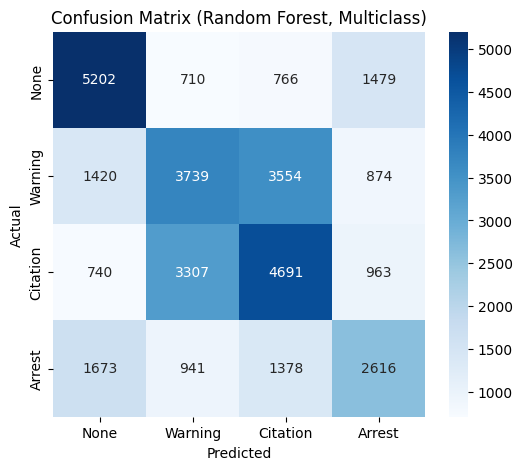

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

labels = ['None', 'Warning', 'Citation', 'Arrest']
cm = confusion_matrix(y_test, pred, labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Random Forest, Multiclass)")
plt.show()

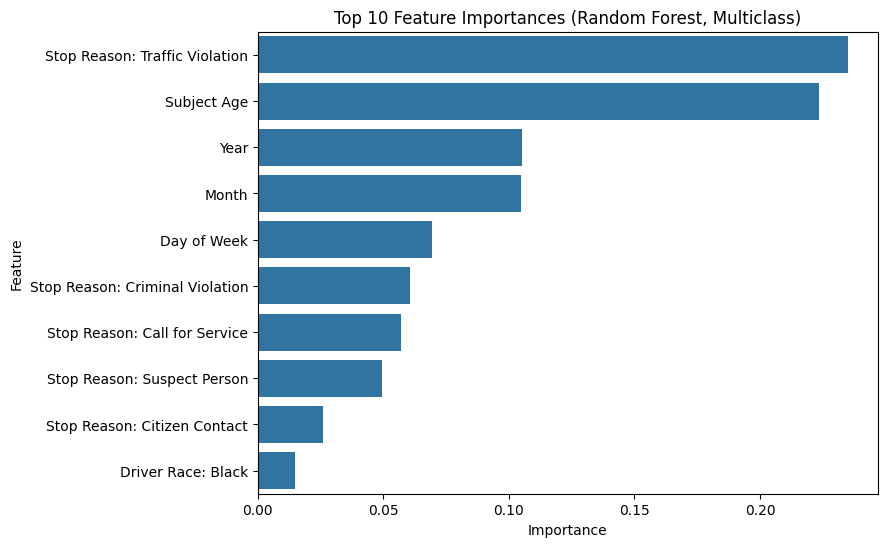

In [23]:
fi["feature_clean"] = fi["feature"].replace(rename_dict)
plt.figure(figsize=(8, 6))
sns.barplot(data=fi.head(10), x='importance', y='feature_clean')
plt.title('Top 10 Feature Importances (Random Forest, Multiclass)')
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Multinomial Logistic Regression

In [24]:
#Statistical Model
import pandas as pd
import numpy as np
import scipy as scp
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn.metrics import confusion_matrix

import statsmodels.api as sm
import matplotlib.pyplot as plt


#pulling out relevant variables
clean_stops = stops[['outcome', 'subject_age', 'subject_sex', 'subject_race', 'lat', 'lng', 'stop_month']].copy()
clean_stops['outcome'] = clean_stops['outcome'].fillna('None')
clean_stops = clean_stops.dropna()

#encoding predictors
X = clean_stops.drop(columns=['outcome'])
X = pd.get_dummies(X, drop_first=True)

#response
y = clean_stops[['outcome']].copy()
y['outcome'] = y['outcome'].astype('category').cat.set_categories(new_categories=['None', 'Citation', 'Arrest', 'Warning'])

In [25]:
#Adding a column of constants to act as the intercept
X = sm.add_constant(X, prepend=False)

#Fitting the model
logit_model=sm.MNLogit(y, X.astype(float))
logit_model
result=logit_model.fit()
stats1=result.summary()
stats2=result.summary2()

Optimization terminated successfully.
         Current function value: 1.305667
         Iterations 8


In [26]:
print(stats1)

                          MNLogit Regression Results                          
Dep. Variable:                outcome   No. Observations:               166986
Model:                        MNLogit   Df Residuals:                   166953
Method:                           MLE   Df Model:                           30
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                 0.02064
Time:                        21:23:53   Log-Likelihood:            -2.1803e+05
converged:                       True   LL-Null:                   -2.2262e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
     outcome=Citation       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
subject_age               0.0115      0.001     20.143      0.000       0.010       0.013
lat                       0.0480      0.265      0.181      0.856      -0.471       0.567
lng     

In [27]:
print(stats2)

                              Results: MNLogit
Model:                  MNLogit             Method:              MLE        
Dependent Variable:     outcome             Pseudo R-squared:    0.021      
Date:                   2026-04-08 21:23    AIC:                 436122.1301
No. Observations:       166986              BIC:                 436452.9771
Df Model:               30                  Log-Likelihood:      -2.1803e+05
Df Residuals:           166953              LL-Null:             -2.2262e+05
Converged:              1.0000              LLR p-value:         0.0000     
No. Iterations:         8.0000              Scale:               1.0000     
----------------------------------------------------------------------------
      outcome = 0         Coef.   Std.Err.    t     P>|t|   [0.025   0.975] 
----------------------------------------------------------------------------
          subject_age      0.0115   0.0006  20.1432 0.0000   0.0104   0.0126
                  lat      0.